### Quantum state preparation
#This note book will show quantum state preparation in different contexts: we will start with n=1 case and n=2, and then we will generalize to general #n for real and complex amplitudes. 

In [25]:
%pip install matplotlib pylatexenc

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [18]:
!pip install qiskit[visualization]

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit import Parameter
from IPython.display import display

In [2]:

alpha2 = Parameter("α2")

qc = QuantumCircuit(1)
qc.ry(2 * alpha2, 0)

print(qc.draw())

   ┌──────────┐
q: ┤ Ry(2*α2) ├
   └──────────┘


# The goal here is to prepare a state $|\psi\rangle = Cos\alpha |0\rangle +Sin\alpha|1\rangle$. Recall that this can be achieved easily by acting with $R_y (\theta)$ on the state $|0\rangle$ that is $(1 0)$ where you will get a vector of the form $(cos(\theta/2)   sin(\theta/2))$ which means the angle $\theta/2$ should be $\alpha$. That puts the argument of $R_y$ to be $2 \alpha.$

In [1]:
#let's give \alpha a specific number
alpha = np.pi / 6

qc = QuantumCircuit(1)
qc.ry(2 * alpha, 0)

state = Statevector.from_instruction(qc)

print(qc.draw())
print(state)

   ┌─────────┐
q: ┤ Ry(π/3) ├
   └─────────┘
Statevector([0.8660254+0.j, 0.5      +0.j],
            dims=(2,))


# Now let's say you want to prepare a complex state where $|\psi> = \psi_0|0\rangle+\psi_1|1\rangle$ where $\psi_0 =|\psi_0| e^{i \phi_0}$ and $\psi_1 = |\psi_1| e^{i \phi_1}$ . For normalized $n=1$ qubit state we have $|\psi_0|^2 +|\psi_1|^2 =1$. This will mean we prepare the state as we have done before and then we apply a phase. Recall that one can always factor out a global phase (it doesn't matter physically aka it is not an observable) $|\psi\rangle = |\psi_0||0\rangle+e^{i \delta}|\psi_1||1\rangle$. The phase gate that we will finally apply will be $P(\delta)=\left(\begin{smallmatrix} 1 & 0 \\ 0 & e^{i\delta} \end{smallmatrix}\right)$ 

In [8]:
a = complex(2,4)  # amplitude of |0>
b = complex(2,4)  # amplitude of |1>

norm = np.sqrt(abs(a)**2 + abs(b)**2)
a, b = a / norm, b / norm

alpha = np.arctan2(abs(b), abs(a))
delta = np.angle(b) - np.angle(a)

qc = QuantumCircuit(1)
qc.ry(2 * alpha, 0)
qc.p(delta, 0)
print(qc.draw())
print(state)

   ┌─────────┐┌──────┐
q: ┤ Ry(π/2) ├┤ P(0) ├
   └─────────┘└──────┘
Statevector([0.8660254+0.j, 0.5      +0.j],
            dims=(2,))


In [9]:
# we will pick specific amplitudes. You either know the amplitudes or the angle
psi0_abs = np.sqrt(0.3)
psi1_abs = np.sqrt(0.7)
delta = np.pi / 3

alpha = np.arctan2(psi1_abs, psi0_abs)

qc = QuantumCircuit(1)
qc.ry(2 * alpha, 0)
qc.p(delta, 0)

state = Statevector.from_instruction(qc)

print(qc.draw())
print(state)

   ┌────────────┐┌────────┐
q: ┤ Ry(1.9823) ├┤ P(π/3) ├
   └────────────┘└────────┘
Statevector([0.54772256+0.j        , 0.41833001+0.72456884j],
            dims=(2,))


## $n =2$ case

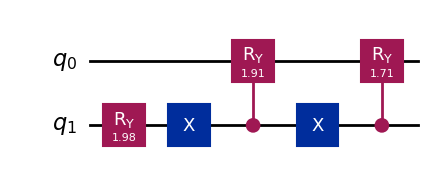

Statevector([0.31622777+0.j, 0.4472136 +0.j, 0.54772256+0.j,
             0.63245553+0.j],
            dims=(2, 2))


In [3]:
vars_to_clear = ['alpha', 'beta', 'gamma', 'theta','qc']

for var in vars_to_clear:
    globals().pop(var, None)
    
# Desired amplitudes
a00 = np.sqrt(0.1)
a01 = np.sqrt(0.2)
a10 = np.sqrt(0.3)
a11 = np.sqrt(0.4)

# Verify normalization
assert np.isclose(a00**2 + a01**2 + a10**2 + a11**2, 1)

r0 = np.hypot(a00, a01)
r1 = np.hypot(a10, a11)

alpha  = 2 * np.arctan2(r1, r0)
beta = 2 * np.arctan2(a01, a00)
gamma = 2 * np.arctan2(a11, a10)

qc = QuantumCircuit(2)

# apply rotation on the second qubit
qc.ry(alpha, 1)

# Rotate qubit 0 when qubit 1 is |0>
qc.x(1)
qc.cry(beta, 1, 0)
qc.x(1)

# Rotate qubit 0 when qubit 1 is |1>
qc.cry(gamma, 1, 0)

state = Statevector.from_instruction(qc)

figure = qc.draw(output="mpl", style="iqp")
display(figure)
print(state)

## for $n=2$ qubits not assumning real and non negative amplitudes

In [9]:

def prepare_two_qubit_state(amplitudes):
    amplitudes = np.asarray(amplitudes, dtype=complex)

    if len(amplitudes) != 4:
        raise ValueError("Exactly four amplitudes are required.")

    amplitudes /= np.linalg.norm(amplitudes)

    # Magnitudes and phases
    r00, r01, r10, r11 = np.abs(amplitudes)
    phi00, phi01, phi10, phi11 = np.angle(amplitudes)

    # Magnitude-preparation angles
    branch0 = np.hypot(r00, r01)
    branch1 = np.hypot(r10, r11)

    theta = 2 * np.arctan2(branch1, branch0)
    beta  = 2 * np.arctan2(r01, r00)
    gamma_magnitude = 2 * np.arctan2(r11, r10)

    qc = QuantumCircuit(2)

    # Prepare magnitudes
    qc.ry(theta, 1)

    # q1 = 0 branch
    qc.x(1)
    qc.cry(beta, 1, 0)
    qc.x(1)

    # q1 = 1 branch
    qc.cry(gamma_magnitude, 1, 0)

    # each component of the state will recieve a phase, but we can factor out the first one, since again
    #it is a global phase, not a physical observable. upon factoring, we get one phase \lambda_0 = \phi_01-\phi_11
    # acting on the second component of the state. A phase gate acts only on the \(|1\rangle\) component of that qubit:
    #That said, when P(\lambda_0) acts on \psi, it will act on the |1\rangle of the second component of the state
    #and the fourth component of the state |11\rangle. Recall that in qiskit the endian convenction orders the qubits
    #from right to left that is |q_1 q_0\rangle so for the second component |01> where \lambda_0 is acting, 
    #it will act on the first qubit since following this convention, we can see that q_0=1 and q_1=0 which means
    #that the operator P(\lambda_0) will pick the first qubit (because of |1>) to return a phase. 
    #Same when applying P(\lambda_1), mathematically we want it to act on the third compoennt of the state, that is |10>=|q_1 q_0>, 
    #that means circuit-wise, the matrix will act on qubit|1> (because the phase matrix only return something when it acts on |1>). 
    #So P(\lambda_1) will act on the fourth component of the state |11> too. 
    #Finally, we find that mathematically, the last phase we need to apply, the last one that multiplies |11\rangle is \phi_11-\phi_00.
    #but that might not be equal to what we have collected from applying P(\lambda_0) and P(\lmabda_1). Recall that each one of them will 
    #activate on |1> qubit, so the fourth component of the state now, circuit-wise, is recieving \lambda_0 + \lambda_1 total phase. Therefore, 
    #we need a controlled phase that activates only when the control qubit is 1 to give e^{i\some phase correction}|11> which means that our \lambda_0+\lambda_1+\phase correction = \phi_00+\phi_11. 
    #hence, our \phase correction = \phi_11-\phi_00-\lambda_0-\lambda_1= \phi_11-\phi_01-\phi_10+\phi_00.
    # Prepare relative phases
    lambda0 = phi01 - phi00
    lambda1 = phi10 - phi00
    phase_correction = phi11 - phi01 - phi10 + phi00

    qc.p(lambda0, 0)
    qc.p(lambda1, 1)
    qc.cp(phase_correction, 1, 0)

    return qc

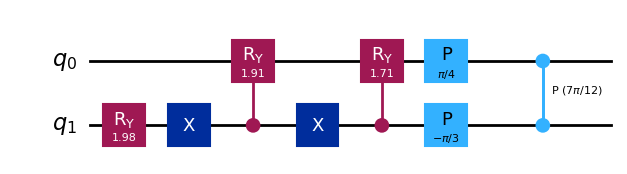

Prepared: [3.16227766e-01+0.j         3.16227766e-01+0.31622777j
 2.73861279e-01-0.47434165j 5.90775593e-17+0.63245553j]
Desired:  [3.16227766e-01+0.j         3.16227766e-01+0.31622777j
 2.73861279e-01-0.47434165j 3.87267321e-17+0.63245553j]


In [10]:
desired = np.array([
    np.sqrt(0.1),
    np.sqrt(0.2) * np.exp(1j * np.pi / 4),
    np.sqrt(0.3) * np.exp(-1j * np.pi / 3),
    np.sqrt(0.4) * np.exp(1j * np.pi / 2)
])

qc = prepare_two_qubit_state(desired)

display(qc.draw(output="mpl", style="iqp"))

prepared = Statevector.from_instruction(qc)

print("Prepared:", prepared.data)
print("Desired: ", desired)

## for general $n$ case

In [4]:
from qiskit.circuit.library import RYGate

vars_to_clear = ['alpha', 'beta', 'gamma', 'theta','qc']

for var in vars_to_clear:
    globals().pop(var, None)

def prepare_nonnegative_state(amplitudes):
    amplitudes = np.asarray(amplitudes, dtype=float)

    # Number of amplitudes must be a power of two
    n = int(np.log2(len(amplitudes)))

    if len(amplitudes) != 2**n:
        raise ValueError("The number of amplitudes must be a power of two.")

    if np.any(amplitudes < 0):
        raise ValueError("All amplitudes must be nonnegative.")

    norm = np.linalg.norm(amplitudes)

    if np.isclose(norm, 0):
        raise ValueError("The amplitude vector cannot be zero.")

    amplitudes = amplitudes / norm
    qc = QuantumCircuit(n)

    # depth = number of previously selected prefix bits
    for depth in range(n):
        target = n - 1 - depth
        block_size = 2 ** (n - depth)
        half_size = block_size // 2

        for prefix in range(2**depth):
            start = prefix * block_size
            middle = start + half_size
            end = start + block_size

            magnitude_0 = np.linalg.norm(amplitudes[start:middle])
            magnitude_1 = np.linalg.norm(amplitudes[middle:end])

            theta = 2 * np.arctan2(magnitude_1, magnitude_0)

            # Higher-indexed qubits control the target
            controls = list(range(target + 1, n))

            if not controls:
                qc.ry(theta, target)
                continue

            # Convert controls on |0> into controls on |1>
            zero_controls = []

            for control in controls:
                desired_bit = (
                    prefix >> (control - target - 1)
                ) & 1

                if desired_bit == 0:
                    qc.x(control)
                    zero_controls.append(control)

            controlled_ry = RYGate(theta).control(len(controls))
            qc.append(controlled_ry, controls + [target])

            # Restore controls
            for control in zero_controls:
                qc.x(control)

    return qc

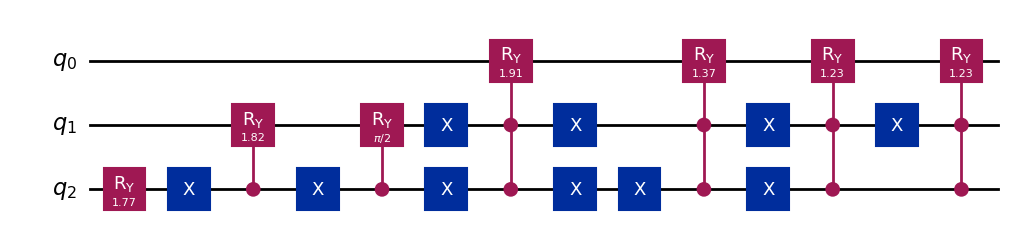

Prepared:
[0.2236068  0.31622777 0.38729833 0.31622777 0.4472136  0.31622777
 0.4472136  0.31622777]
Desired:
[0.2236068  0.31622777 0.38729833 0.31622777 0.4472136  0.31622777
 0.4472136  0.31622777]


In [5]:
amplitudes = np.sqrt([
    0.05, 0.10, 0.15, 0.10,
    0.20, 0.10, 0.20, 0.10
])

qc = prepare_nonnegative_state(amplitudes)

display(qc.draw(output="mpl", style="iqp"))

state = Statevector.from_instruction(qc)

print("Prepared:")
print(np.real_if_close(state.data))

print("Desired:")
print(amplitudes)

## General $n$ case that outputs a circuit U such that $U|0\rangle_n = \sum\psi_x|x\rangle_n$ 

In [17]:
from qiskit.circuit.library import RZGate

def prepare_state(psi, atol=1e-10):
    """
    Construct U such that

        U|0...0> = sum_x psi[x] |x>

    using one-qubit gates and multi-controlled Rz gates.

    Qiskit basis ordering:
        |q_(n-1) ... q_1 q_0>
    """

    psi = np.asarray(psi, dtype=complex).reshape(-1) #To flatten the state vector \psi into an array of complex numbers  
    dimension = len(psi)

    # Check that dimension = 2^n
    #if (dimension & (dimension - 1)) != 0, raise a value error. We are using a property of powers of 2: 2=0010_2,4=0100_2,8,1000_2
    #such that any power of 2 has only one "1" bit followed by zeros on the right and subtracting 1 from that number like 7 forexample
    #flips the 1 to 0 and 0's to the right to 1 like 7=0111_2. so the statement is saying if the dimension is empty or NOT equal to 0000_2, raise an error. 
    if dimension == 0 or dimension & (dimension - 1) !=0: 
        raise ValueError("The vector length must be a power of two.")

    n = int(np.log2(dimension)) #to find n from the dimension of the provided \psi

    if n == 0:
        raise ValueError("At least one qubit is required.")

    norm = np.linalg.norm(psi)

    if not np.isclose(norm, 1.0, atol=atol):
        raise ValueError(f"The state must be normalized; norm = {norm}.")

    qc = QuantumCircuit(n)

    magnitudes = np.abs(psi)
    phases = np.angle(psi)

    # Apply a controlled Rz conditioned on a particular prefix.
    def prefix_controlled_rz(angle, target, prefix, depth):
        if np.isclose(angle, 0.0, atol=atol):
            return

        if depth == 0:
            qc.rz(angle, target)
            return

        # Previously prepared, more-significant qubits
        controls = list(range(n - 1, target, -1))
        zero_controls = []

        # Convert controls on |0> into controls on |1>.
        for position, control in enumerate(controls):
            bit = (prefix >> (depth - 1 - position)) & 1

            if bit == 0:
                qc.x(control)
                zero_controls.append(control)

        gate = RZGate(angle).control(len(controls))
        qc.append(gate, controls + [target])

        # Restore the zero controls.
        for control in reversed(zero_controls):
            qc.x(control)

    # Controlled Ry constructed from a controlled Rz.
    #
    # Ry(theta) = S H Rz(theta) H S†
    def prefix_controlled_ry(angle, target, prefix, depth):
        if np.isclose(angle, 0.0, atol=atol):
            return

        if depth == 0:
            qc.ry(angle, target)
            return

        qc.sdg(target)
        qc.h(target)

        prefix_controlled_rz(
            angle=angle,
            target=target,
            prefix=prefix,
            depth=depth
        )

        qc.h(target)
        qc.s(target)

    # -------------------------------------------------
    # Part 1: Prepare the nonnegative magnitudes
    # -------------------------------------------------

    for depth in range(n):
        target = n - 1 - depth
        block_size = 2 ** (n - depth)
        half_size = block_size // 2

        for prefix in range(2**depth):
            start = prefix * block_size
            middle = start + half_size
            end = start + block_size

            magnitude_zero = np.linalg.norm(
                magnitudes[start:middle]
            )

            magnitude_one = np.linalg.norm(
                magnitudes[middle:end]
            )

            if np.isclose(
                magnitude_zero + magnitude_one, 0.0, atol=atol
            ):
                theta = 0.0
            else:
                theta = 2 * np.arctan2(
                    magnitude_one,
                    magnitude_zero
                )

            prefix_controlled_ry(
                angle=theta,
                target=target,
                prefix=prefix,
                depth=depth
            )

    # -------------------------------------------------
    # Part 2: Add the complex phases
    # -------------------------------------------------

    # The root of the phase tree is the global phase.
    qc.global_phase += np.mean(phases)

    for depth in range(n):
        target = n - 1 - depth
        block_size = 2 ** (n - depth)
        half_size = block_size // 2

        for prefix in range(2**depth):
            start = prefix * block_size
            middle = start + half_size
            end = start + block_size

            mean_phase_zero = np.mean(phases[start:middle])
            mean_phase_one = np.mean(phases[middle:end])

            # Rz(delta) adds -delta/2 to the zero branch
            # and +delta/2 to the one branch.
            delta = mean_phase_one - mean_phase_zero

            prefix_controlled_rz(
                angle=delta,
                target=target,
                prefix=prefix,
                depth=depth
            )

    return qc

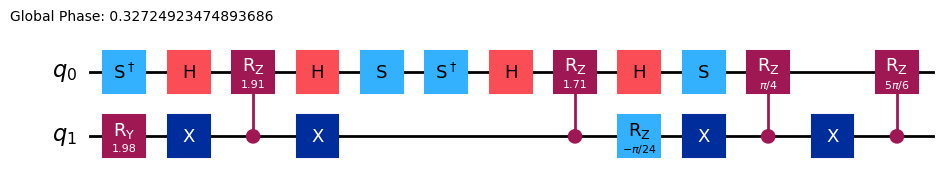

Desired:
[3.16227766e-01+0.j         3.16227766e-01+0.31622777j
 2.73861279e-01-0.47434165j 3.87267321e-17+0.63245553j]

Prepared:
[3.16227766e-01-4.17026462e-17j 3.16227766e-01+3.16227766e-01j
 2.73861279e-01-4.74341649e-01j 8.28165512e-17+6.32455532e-01j]

Correct:
True


In [18]:
#for n=2
psi = np.array([
    np.sqrt(0.1),
    np.sqrt(0.2) * np.exp(1j * np.pi / 4),
    np.sqrt(0.3) * np.exp(-1j * np.pi / 3),
    np.sqrt(0.4) * np.exp(1j * np.pi / 2)
])

qc = prepare_state(psi)

display(qc.draw(output="mpl", style="iqp"))

prepared = Statevector.from_instruction(qc)

print("Desired:")
print(psi)

print("\nPrepared:")
print(prepared.data)

print("\nCorrect:")
print(np.allclose(prepared.data, psi))

Norm: 1.0


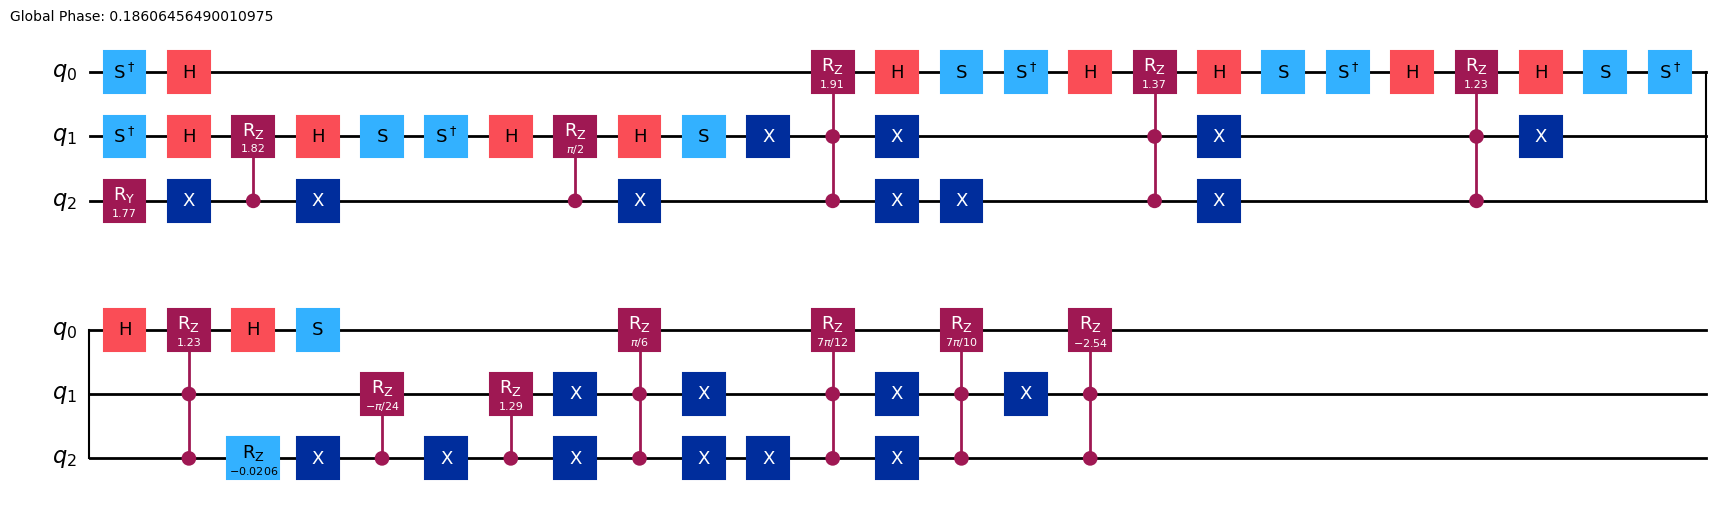

In [14]:
#for n=3
from qiskit.quantum_info import Statevector, state_fidelity

# Probabilities must sum to 1
probabilities = np.array([
    0.05,  # |000>
    0.10,  # |001>
    0.15,  # |010>
    0.10,  # |011>
    0.20,  # |100>
    0.10,  # |101>
    0.20,  # |110>
    0.10   # |111>
])

# Choose an arbitrary phase for every component
phases = np.array([
     0,
     np.pi / 6,
    -np.pi / 4,
     np.pi / 3,
    -np.pi / 2,
     np.pi / 5,
     2 * np.pi / 3,
    -np.pi / 7
])

# psi_x = sqrt(p_x) exp(i phi_x)
psi = np.sqrt(probabilities) * np.exp(1j * phases)

print("Norm:", np.linalg.norm(psi))

qc = prepare_state(psi)

display(qc.draw(output="mpl", style="iqp"))

In [15]:
prepared = Statevector.from_instruction(qc)
desired = Statevector(psi)

print("Desired state:")
print(desired)

print("\nPrepared state:")
print(prepared)

print("\nVectors equal:")
print(np.allclose(prepared.data, psi, atol=1e-10))

print("\nFidelity:")
print(state_fidelity(prepared, desired))

Desired state:
Statevector([ 2.23606798e-01+0.j        ,  2.73861279e-01+0.15811388j,
              2.73861279e-01-0.27386128j,  1.58113883e-01+0.27386128j,
              2.73839349e-17-0.4472136j ,  2.55833637e-01+0.18587402j,
             -2.23606798e-01+0.38729833j,  2.84911372e-01-0.13720609j],
            dims=(2, 2, 2))

Prepared state:
Statevector([ 2.23606798e-01+6.31134338e-17j,
              2.73861279e-01+1.58113883e-01j,
              2.73861279e-01-2.73861279e-01j,
              1.58113883e-01+2.73861279e-01j,
             -2.70636731e-16-4.47213595e-01j,
              2.55833637e-01+1.85874017e-01j,
             -2.23606798e-01+3.87298335e-01j,
              2.84911372e-01-1.37206086e-01j],
            dims=(2, 2, 2))

Vectors equal:
True

Fidelity:
0.9999999999999989


In [16]:
#To inspect each amplitude separately:
for x, (wanted, obtained) in enumerate(
    zip(psi, prepared.data)
):
    label = format(x, "03b")

    print(
        f"|{label}>: "
        f"desired = {wanted:.6f}, "
        f"prepared = {obtained:.6f}"
    )

|000>: desired = 0.223607+0.000000j, prepared = 0.223607+0.000000j
|001>: desired = 0.273861+0.158114j, prepared = 0.273861+0.158114j
|010>: desired = 0.273861-0.273861j, prepared = 0.273861-0.273861j
|011>: desired = 0.158114+0.273861j, prepared = 0.158114+0.273861j
|100>: desired = 0.000000-0.447214j, prepared = -0.000000-0.447214j
|101>: desired = 0.255834+0.185874j, prepared = 0.255834+0.185874j
|110>: desired = -0.223607+0.387298j, prepared = -0.223607+0.387298j
|111>: desired = 0.284911-0.137206j, prepared = 0.284911-0.137206j
